# How long does Chicago take to fix things, and does it depend on where you live?

**Question:** how long does the city take to close 311 requests for potholes, street lights, graffiti, rats, and abandoned vehicles, and does the wait depend on the neighborhood?

**Data:** [311 Service Requests](https://data.cityofchicago.org/Service-Requests/311-Service-Requests/v6vf-nfxy) from the City of Chicago Data Portal, plus community-area boundaries and American Community Survey (ACS) income estimates from the same portal. Run `python scripts/download.py` and `python scripts/build.py` first. This notebook only reads `data/311.duckdb` and saves charts to `charts/`.

**Measure:** days to close = `closed_date - created_date`. "Closed" is the city's record that the job is done, which is not always the moment the problem was fixed (see Limitations).

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch, Polygon
from scipy import stats

con = duckdb.connect("data/311.duckdb", read_only=True)


def q(sql):
    """Run SQL against the DuckDB database and return a pandas DataFrame."""
    return con.sql(sql).df()


YEAR = 2025  # the last full year; the current year is partial and many of its requests are still open
POTHOLE = "Pothole in Street Complaint"
STREET_LIGHT = "Street Light Out Complaint"
SHORT = {
    "Pothole in Street Complaint": "Potholes",
    "Street Light Out Complaint": "Street lights",
    "Graffiti Removal Request": "Graffiti",
    "Rodent Baiting/Rat Complaint": "Rats",
    "Abandoned Vehicle Complaint": "Abandoned vehicles",
}
Path("charts").mkdir(exist_ok=True)
pd.set_option("display.float_format", "{:,.1f}".format)

In [2]:
# Chart style: light surface, hairline grid, blue for a single series, blue and orange for pairs.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10.5, "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight",
})


def titles(fig, title, subtitle, pad=0.25):
    """Left-aligned title and subtitle above the top of the plots (pad = extra inches of space)."""
    for ax in fig.axes:
        ax.apply_aspect()
    top = max(ax.get_position().y1 for ax in fig.axes)
    height = fig.get_size_inches()[1]
    fig.text(0.0, top + (pad + 0.32) / height, title, fontsize=14, fontweight="bold", color=INK)
    fig.text(0.0, top + pad / height, subtitle, fontsize=10.5, color=INK_2)


def source_note(fig, pad=0.6):
    """Source line below the bottom of the plots (pad = inches of space for axis labels)."""
    bottom = min(ax.get_position().y0 for ax in fig.axes)
    fig.text(0.0, bottom - pad / fig.get_size_inches()[1],
             "Source: City of Chicago 311 Service Requests (data.cityofchicago.org). "
             "Analysis: github.com/Dipzinski/chicago-311-response-times", fontsize=8, color=MUTED)

## 1. The data

In [3]:
q("""
SELECT sr_type, rows_downloaded,
       strftime(downloaded_before - INTERVAL 1 DAY, '%Y-%m-%d') AS data_through
FROM download_log
ORDER BY rows_downloaded DESC
""")

,sr_type,rows_downloaded,data_through
0,Graffiti Removal Request,718835,2026-09-28
1,Pothole in Street Complaint,425770,2026-09-28
2,Street Light Out Complaint,398822,2026-09-28
3,Rodent Baiting/Rat Complaint,384302,2026-09-28
4,Abandoned Vehicle Complaint,334271,2026-09-28


In [4]:
q("""
SELECT count(*) AS requests,
       min(created_date)::DATE AS first_created,
       max(created_date)::DATE AS last_created
FROM raw_requests
""")

,requests,first_created,last_created
0,2262000,2019-01-01,2026-09-28


## 2. Cleaning: what was removed, and why it matters

`sql/01_clean.sql` gives every request an `exclude_reason` (NULL means kept). The rules run in order, so each request is counted under the first rule that applies.

In [5]:
removed = q("""
SELECT coalesce(exclude_reason, 'kept') AS outcome,
       count(*) AS requests,
       100.0 * count(*) / sum(count(*)) OVER () AS pct_of_downloaded
FROM requests
GROUP BY 1
ORDER BY requests DESC
""")
removed

,outcome,requests,pct_of_downloaded
0,kept,1572661,69.5
1,duplicate,311036,13.8
2,city-logged work,295973,13.1
3,closed within 1 hour,70064,3.1
4,canceled,12266,0.5


**City-logged work.** The dataset says some origins "result from the City's own operations". They close almost instantly because the crew enters the job after doing it:

In [6]:
q("""
SELECT sr_type, origin, count(*) AS requests,
       median(days_to_close) * 24 * 60 AS median_minutes_to_close
FROM requests
WHERE exclude_reason = 'city-logged work'
GROUP BY ALL
HAVING count(*) > 1000
ORDER BY requests DESC
""")

,sr_type,origin,requests,median_minutes_to_close
0,Graffiti Removal Request,Mass Entry,279319,0.1
1,Pothole in Street Complaint,Generated In House,12055,1.0
2,Street Light Out Complaint,WOFromTerraGo,4200,0.4


**Closed within 1 hour.** A crew can rarely be sent out that fast, yet a large share of pothole requests entered by phone close within an hour. Two clues say these are city staff logging work already done, not residents waiting: phone requests do it far more often than app or web requests for the same problem, and it happens only during the workday, although 311 takes calls around the clock.

In [7]:
fast = q("""
SELECT sr_type,
       CASE WHEN origin = 'Phone Call' THEN 'Phone call' ELSE 'Other channels' END AS channel,
       count(*) AS completed,
       100.0 * avg((closed_date < created_date + INTERVAL 1 HOUR)::INT) AS pct_closed_within_1h,
       100.0 * avg((closed_date < created_date + INTERVAL 1 HOUR)::INT)
             FILTER (WHERE hour(created_date) BETWEEN 7 AND 14) AS pct_if_created_7am_to_3pm,
       100.0 * avg((closed_date < created_date + INTERVAL 1 HOUR)::INT)
             FILTER (WHERE hour(created_date) >= 16) AS pct_if_created_after_4pm
FROM requests
WHERE status = 'Completed' AND (exclude_reason IS NULL OR exclude_reason = 'closed within 1 hour')
GROUP BY ALL
ORDER BY sr_type, channel
""")
fast

,sr_type,channel,completed,pct_closed_within_1h,pct_if_created_7am_to_3pm,pct_if_created_after_4pm
0,Abandoned Vehicle Complaint,Other channels,203790,3.5,5.2,0.1
1,Abandoned Vehicle Complaint,Phone call,117969,0.4,0.5,0.1
2,Graffiti Removal Request,Other channels,320256,2.8,4.9,0.0
3,Graffiti Removal Request,Phone call,89537,1.4,1.9,0.0
4,Pothole in Street Complaint,Other channels,148025,0.2,0.3,0.0
5,Pothole in Street Complaint,Phone call,126526,36.6,45.0,1.5
6,Rodent Baiting/Rat Complaint,Other channels,232409,0.0,0.0,0.0
7,Rodent Baiting/Rat Complaint,Phone call,134696,0.9,1.2,0.0
8,Street Light Out Complaint,Other channels,96184,0.2,0.6,0.1
9,Street Light Out Complaint,Phone call,153505,2.9,7.0,0.8


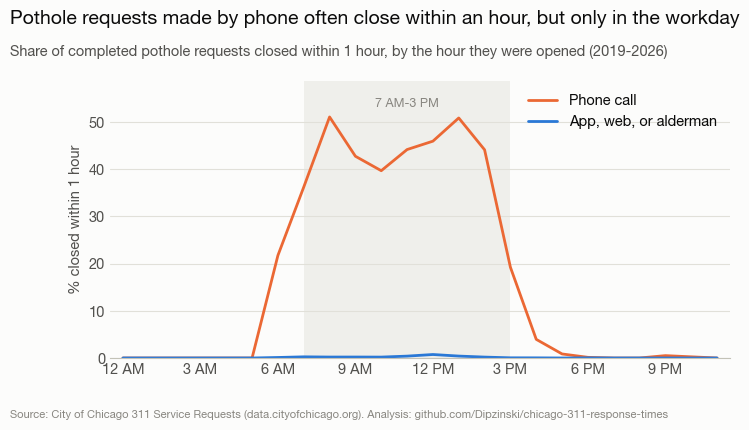

In [8]:
by_hour = q(f"""
SELECT hour(created_date) AS hour,
       CASE WHEN origin = 'Phone Call' THEN 'Phone call' ELSE 'App, web, or alderman' END AS channel,
       100.0 * avg((closed_date < created_date + INTERVAL 1 HOUR)::INT) AS pct_closed_within_1h
FROM requests
WHERE sr_type = '{POTHOLE}' AND status = 'Completed'
  AND (exclude_reason IS NULL OR exclude_reason = 'closed within 1 hour')
GROUP BY ALL
ORDER BY hour
""").pivot(index="hour", columns="channel", values="pct_closed_within_1h")

fig, ax = plt.subplots(figsize=(8, 3.6))
for channel, color in [("Phone call", ORANGE), ("App, web, or alderman", BLUE)]:
    ax.plot(by_hour.index, by_hour[channel], color=color, label=channel)
ax.axvspan(7, 15, color=GRID, alpha=0.45, lw=0)
ax.text(11, by_hour.max().max() * 1.03, "7 AM-3 PM", ha="center", va="bottom", fontsize=9, color=MUTED)
ax.set_xticks(range(0, 24, 3), ["12 AM", "3 AM", "6 AM", "9 AM", "12 PM", "3 PM", "6 PM", "9 PM"])
ax.set_ylabel("% closed within 1 hour")
ax.set_ylim(0, by_hour.max().max() * 1.15)
ax.set_xlim(-0.5, 23.5)
ax.legend(loc="upper right")
titles(fig, "Pothole requests made by phone often close within an hour, but only in the workday",
       "Share of completed pothole requests closed within 1 hour, by the hour they were opened (2019-2026)")
source_note(fig)
fig.savefig("charts/1_instant_closures.png")
plt.show()

**Does it matter?** Pothole median days to close for requests created in 2024-2025, with and without those two rules:

In [9]:
sensitivity = q(f"""
SELECT
    median(days_to_close) FILTER (WHERE exclude_reason IS NULL) AS cleaned,
    median(days_to_close) FILTER (WHERE status = 'Completed' AND (exclude_reason IS NULL
        OR exclude_reason IN ('city-logged work', 'closed within 1 hour'))) AS keeping_city_logged_and_1_hour
FROM requests
WHERE sr_type = '{POTHOLE}' AND year IN (2024, 2025)
""")
sensitivity["understated_by_pct"] = 100 * (1 - sensitivity.keeping_city_logged_and_1_hour / sensitivity.cleaned)
sensitivity

,cleaned,keeping_city_logged_and_1_hour,understated_by_pct
0,9.9,5.6,43.5


## 3. Citywide: median days to close, by year

In [10]:
city = q("SELECT * FROM city_year_type")
city.pivot(index="sr_type", columns="year", values="median_days").rename(index=SHORT)

year,2019,2020,2021,2022,2023,2024,2025,2026
sr_type,,,,,,,,
Abandoned vehicles,13.8,16.0,12.7,21.7,9.0,11.8,10.9,11.8
Graffiti,1.2,0.9,1.0,1.0,1.0,1.0,1.0,1.0
Potholes,24.9,5.7,8.1,10.9,6.7,7.5,13.5,8.8
Rats,3.0,6.1,10.4,8.9,6.8,4.0,3.7,3.7
Street lights,27.6,13.4,4.8,4.9,3.0,2.8,2.4,2.7


Open requests have no close date, so medians use closed requests only. That could hide long waits, so check how many are still open. The last full year is barely affected (1.7% at most). The current year is affected, which is why trends stop at the last full year. One oddity: 18.6% of 2020 abandoned-vehicle requests, mostly from February to July 2020, were never closed, so that year's median for abandoned vehicles is not reliable.

In [11]:
city.assign(pct_still_open=100 * city.still_open / city.requests).pivot(
    index="sr_type", columns="year", values="pct_still_open").rename(index=SHORT)

year,2019,2020,2021,2022,2023,2024,2025,2026
sr_type,,,,,,,,
Abandoned vehicles,0.0,18.6,0.0,0.7,0.3,0.5,0.6,5.8
Graffiti,0.0,0.0,0.0,0.0,0.0,0.3,1.7,1.9
Potholes,0.0,0.0,0.0,0.0,0.0,0.1,0.3,18.5
Rats,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.6
Street lights,0.0,0.0,0.0,0.3,0.6,0.8,1.4,4.1


## 4. Potholes: the wait depends heavily on the neighborhood

**Test:** Kruskal-Wallis across the 77 community areas, for each request type in the last full year. It compares ranks, so a few extreme waits don't dominate. With thousands of requests almost any difference is "significant", so the effect size is the number to compare: ε² = H / (n - 1) is the share of the variation in ranks explained by the area (0 = none, 1 = all).

In [12]:
def area_groups(sr_type, year):
    d = q(f"""SELECT community_area, days_to_close FROM kept
              WHERE sr_type = '{sr_type}' AND year = {year}
                AND days_to_close IS NOT NULL AND community_area IS NOT NULL""")
    return d, [g.days_to_close.to_numpy() for _, g in d.groupby("community_area")]


rows = []
for sr_type, short in SHORT.items():
    d, groups = area_groups(sr_type, YEAR)
    h, p = stats.kruskal(*groups)
    rows.append({"request_type": short, "closed_requests": len(d), "areas": len(groups),
                 "H": f"{h:,.0f}", "p_value": "< 0.001" if p < 0.001 else f"{p:.3f}",
                 "epsilon_squared": h / (len(d) - 1)})
kruskal = pd.DataFrame(rows).sort_values("epsilon_squared", ascending=False)
kruskal.style.format({"closed_requests": "{:,}", "epsilon_squared": "{:.3f}"}).hide(axis="index")

request_type,closed_requests,areas,H,p_value,epsilon_squared
Potholes,"20,796",77,"3,734",< 0.001,0.180
Street lights,"29,688",77,769,< 0.001,0.026
Graffiti,"57,493",77,"1,451",< 0.001,0.025
Abandoned vehicles,"51,662",77,"1,176",< 0.001,0.023
Rats,"42,995",77,518,< 0.001,0.012


Potholes have by far the largest area effect. Which areas are slowest? Take the slowest 10% of the 77 areas (8 areas) by median days in the last full year.

In [13]:
area = q("SELECT * FROM area_year_type")
pothole_areas = area[area.sr_type == POTHOLE]
last_year = pothole_areas[pothole_areas.year == YEAR].sort_values("median_days", ascending=False)
slowest = last_year.head(8)
slowest[["community_area", "community_area_name", "closed", "median_days", "p90_days"]]

,community_area,community_area_name,closed,median_days,p90_days
1837,76,O'Hare,86,53.6,170.7
1381,19,Belmont Cragin,466,46.8,137.8
1413,23,Humboldt Park,256,45.1,150.8
1317,11,Jefferson Park,208,44.2,130.8
1461,29,North Lawndale,168,43.4,132.1
1429,25,Austin,448,42.8,143.3
1437,26,West Garfield Park,126,40.0,133.1
1445,27,East Garfield Park,158,38.8,134.8


In [14]:
slow_ids = ", ".join(str(a) for a in slowest.community_area)
compare = q(f"""
SELECT year,
       CASE WHEN community_area IN ({slow_ids}) THEN 'slowest_8' ELSE 'rest_of_city' END AS grp,
       median(days_to_close) AS median_days
FROM kept
WHERE sr_type = '{POTHOLE}' AND community_area IS NOT NULL AND year <= {YEAR}
GROUP BY ALL
""").pivot(index="year", columns="grp", values="median_days")
compare["times_longer"] = compare.slowest_8 / compare.rest_of_city
compare

grp,rest_of_city,slowest_8,times_longer
year,,,
2019,22.0,44.1,2.0
2020,5.1,13.9,2.7
2021,7.6,21.6,2.8
2022,10.7,13.2,1.2
2023,6.1,12.1,2.0
2024,7.1,11.9,1.7
2025,11.9,43.2,3.6


The 8 areas were picked using the last full year only, so the earlier years are a check on whether they are consistently slow or just unlucky in one year. Another check: do areas keep their rank from one year to the next?

In [15]:
ranks = pothole_areas.pivot(index="community_area", columns="year", values="median_days")
rho, p = stats.spearmanr(ranks[YEAR - 1], ranks[YEAR])
print(f"Spearman correlation of area medians, {YEAR - 1} vs {YEAR}: rho = {rho:.2f} (p = {p:.1e})")

Spearman correlation of area medians, 2024 vs 2025: rho = 0.47 (p = 1.3e-05)


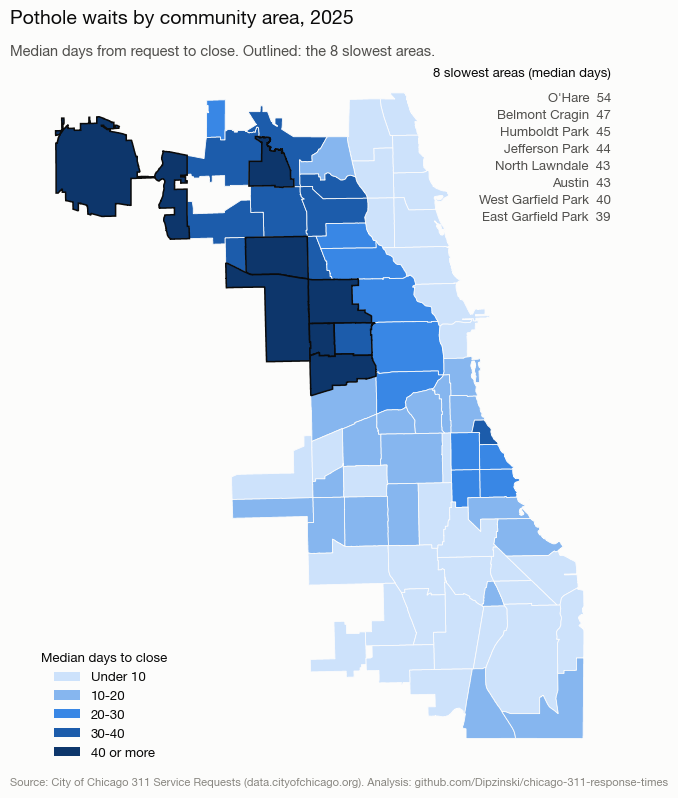

In [16]:
geo = json.loads(Path("exports/community_areas.geojson").read_text())
median_by_area = last_year.set_index("community_area").median_days
bins = [0, 10, 20, 30, 40, np.inf]
labels = ["Under 10", "10-20", "20-30", "30-40", "40 or more"]
colors = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]

fig, ax = plt.subplots(figsize=(6.2, 7.4))
fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
for feature in geo["features"]:
    area_id = feature["properties"]["community_area"]
    color = colors[np.digitize(median_by_area[area_id], bins) - 1]
    is_slow = area_id in set(slowest.community_area)
    for polygon in feature["geometry"]["coordinates"]:
        ax.add_patch(Polygon(polygon[0], closed=True, facecolor=color,
                             edgecolor=INK if is_slow else SURFACE, linewidth=1.1 if is_slow else 0.6,
                             zorder=3 if is_slow else 2))
ax.set_aspect(1 / np.cos(np.radians(41.84)))  # degrees of longitude are shorter than latitude here
ax.autoscale_view()
ax.axis("off")
ax.legend(handles=[Patch(facecolor=c, label=l) for c, l in zip(colors, labels)],
          title="Median days to close", loc="lower left", fontsize=9.5, title_fontsize=9.5)
slow_list = "\n".join(f"{r.community_area_name}  {r.median_days:.0f}" for r in slowest.itertuples())
ax.text(1.0, 0.99, "8 slowest areas (median days)", transform=ax.transAxes, ha="right", va="top",
        fontsize=9.5, fontweight="bold", color=INK)
ax.text(1.0, 0.955, slow_list, transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
        color=INK_2, linespacing=1.55)
titles(fig, f"Pothole waits by community area, {YEAR}",
       "Median days from request to close. Outlined: the 8 slowest areas.", pad=0.05)
source_note(fig, pad=0.15)
fig.savefig("charts/2_pothole_map.png")
plt.show()

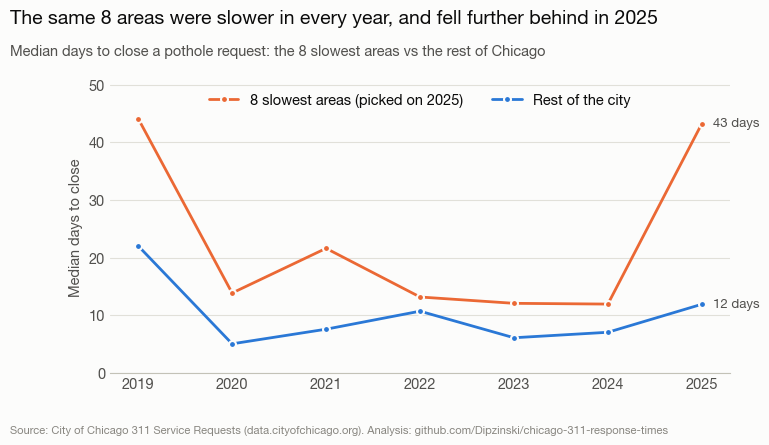

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.8))
series = [("slowest_8", f"8 slowest areas (picked on {YEAR})", ORANGE), ("rest_of_city", "Rest of the city", BLUE)]
for col, label, color in series:
    ax.plot(compare.index, compare[col], color=color, label=label, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.annotate(f"{compare[col].iloc[-1]:.0f} days", (compare.index[-1], compare[col].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9.5, color=INK_2)
ax.set_ylabel("Median days to close")
ax.set_ylim(0, compare[["slowest_8", "rest_of_city"]].max().max() * 1.15)
ax.set_xticks(compare.index)
ax.legend(loc="upper center", ncol=2)
titles(fig, "The same 8 areas were slower in every year, and fell further behind in 2025",
       "Median days to close a pothole request: the 8 slowest areas vs the rest of Chicago")
source_note(fig)
fig.savefig("charts/3_slowest_vs_rest.png")
plt.show()

## 5. Income: lower-income areas do not wait longer

Income measure: the share of families earning under $50,000 a year (ACS 5-year estimates, aggregated to community areas by the city). Test: Spearman rank correlation between that share and each area's median days to close, one test per request type, with a Bonferroni correction for running 5 tests (multiply each p-value by 5). A positive rho would mean lower-income areas wait longer.

In [18]:
income = q("SELECT community_area, pct_families_under_50k FROM area_income")
merged = area[area.year == YEAR].merge(income, on="community_area")
rows = []
for sr_type, short in SHORT.items():
    g = merged[merged.sr_type == sr_type]
    rho, p = stats.spearmanr(g.pct_families_under_50k, g.median_days)
    rows.append({"request_type": short, "areas": len(g), "spearman_rho": rho,
                 "p_value": p, "p_bonferroni": min(1.0, p * len(SHORT))})
income_tests = pd.DataFrame(rows)
income_tests.style.format({"spearman_rho": "{:+.2f}", "p_value": "{:.4f}", "p_bonferroni": "{:.4f}"}).hide(axis="index")

request_type,areas,spearman_rho,p_value,p_bonferroni
Potholes,77,+0.06,0.6122,1.0000
Street lights,77,-0.01,0.9189,1.0000
Graffiti,77,+0.02,0.8591,1.0000
Rats,77,-0.32,0.0048,0.0239
Abandoned vehicles,77,-0.22,0.0573,0.2867


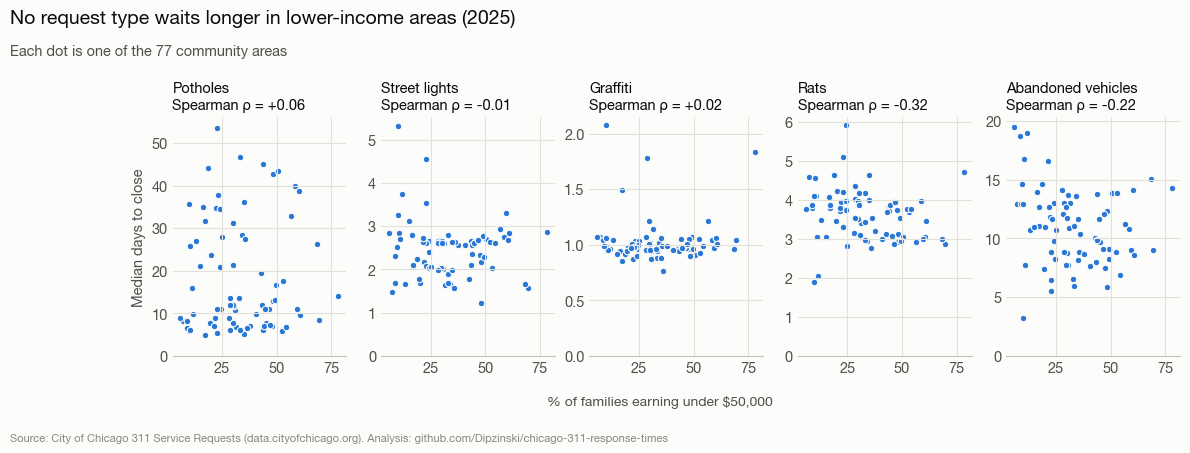

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.1), sharex=True)
for ax, (sr_type, short) in zip(axes, SHORT.items()):
    g = merged[merged.sr_type == sr_type]
    rho = income_tests.set_index("request_type").loc[short, "spearman_rho"]
    ax.scatter(g.pct_families_under_50k, g.median_days, s=22, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
    ax.set_title(f"{short}\nSpearman ρ = {rho:+.2f}", fontsize=10.5, loc="left", color=INK)
    ax.set_ylim(0, None)
    ax.grid(axis="x")
axes[0].set_ylabel("Median days to close")
fig.supxlabel("% of families earning under $50,000", fontsize=10, color=INK_2, y=-0.06)
titles(fig, f"No request type waits longer in lower-income areas ({YEAR})",
       "Each dot is one of the 77 community areas", pad=0.62)
source_note(fig, pad=0.85)
fig.savefig("charts/4_income.png")
plt.show()

## 6. Street lights: requests now close in days, not weeks

In [20]:
lights = city[(city.sr_type == STREET_LIGHT) & (city.year <= YEAR)].set_index("year")
lights[["requests", "median_days", "p90_days"]]

,requests,median_days,p90_days
year,,,
2019,33772,27.6,121.6
2020,33141,13.4,42.1
2021,34349,4.8,17.2
2022,32152,4.9,41.5
2023,29335,3.0,17.3
2024,30937,2.8,14.3
2025,30177,2.4,12.1


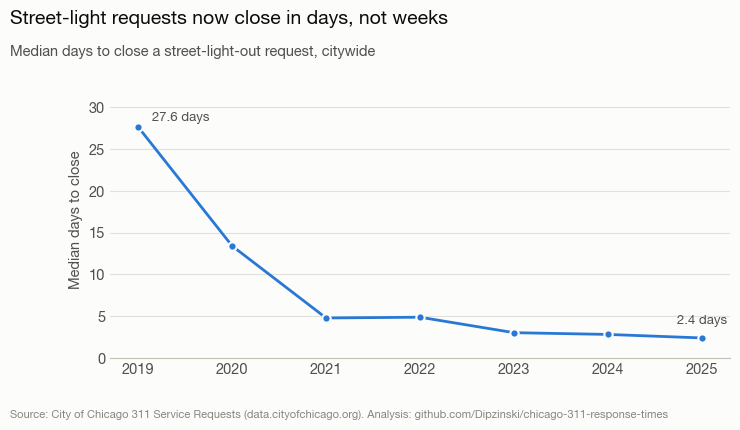

In [21]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(lights.index, lights.median_days, color=BLUE, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
first, last = lights.index[0], lights.index[-1]
ax.annotate(f"{lights.median_days[first]:.1f} days", (first, lights.median_days[first]),
            xytext=(10, 2), textcoords="offset points", ha="left", va="bottom", fontsize=9.5, color=INK_2)
ax.annotate(f"{lights.median_days[last]:.1f} days", (last, lights.median_days[last]),
            xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9.5, color=INK_2)
ax.set_ylabel("Median days to close")
ax.set_ylim(0, lights.median_days.max() * 1.2)
ax.set_xticks(lights.index)
titles(fig, "Street-light requests now close in days, not weeks",
       "Median days to close a street-light-out request, citywide")
source_note(fig)
fig.savefig("charts/5_street_lights.png")
plt.show()

## 7. Limitations

- **Closed is not the same as fixed.** A request closes when the city marks it done. It can close after an inspection finds nothing to fix, and the dataset has no resolution code.
- **311 reflects who reports, not where problems are.** Areas that call more have more requests; request counts are not a measure of need.
- **The 1-hour rule is a judgment call.** A few real, very fast repairs are dropped with the crew-logged entries. Section 2 shows what changes without the rule.
- **Small areas are noisy.** Some community areas have fewer than 100 pothole requests a year, so their medians move a lot between years.
- **Income is an estimate.** The ACS figures are 5-year survey estimates, re-aggregated from census tracts to community areas by the city.
- **Correlation is not cause.** The tests show where waits differ, not why (crew districts, street types, weather, and budgets are not in the data).